# Community Detection Protein Interaction
***Analyzing Protein-Pretein Interaction Networks with Random Walk - Markov Clustering inflation rate [3,2,1]***

In [20]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import markov_clustering as mc

# Load Data
***Restore header: Source, Target, weight***

In [8]:
column_names = ["source", "target", "weight"]
community = pd.read_csv(r'D:\BNFO286\Kaggle\bnfo286interaction\network_with_weights.edgelist', header = None,
                        names=column_names, sep="\t")

community["weight"] = community["weight"].astype(float)
community.head()

,source,target,weight
0,MAL944N3R,2P070I351,0.981574
1,LPAXLZS35,2IUMVXWR8,0.977001
2,IYMKO9LF4,017MQ4ZTB,0.975498
3,6CJFVPO4U,P86LCJZFV,0.974873
4,LBTT9SRNJ,DYH3UPRT6,0.970838


In [15]:
G = nx.Graph()
for _, row in community.iterrows():
    G.add_edge(row["source"], row["target"], weight=float(row["weight"]))

# Run Markov Clustering algorithm
***Inflation rate [1.5, 2, 2.5, 3, 3.5]***

In [44]:
# Convert Graph to Adjacency Matrix
adj_matrix = nx.to_numpy_array(G, nodelist=list(G.nodes()))

# Define inflation rates to test
inflation_values = [1.5, 2, 2.5, 3, 3.5]
cluster_counts = {}

#MCL
for inflation in inflation_values:
    result = mc.run_mcl(adj_matrix, inflation=inflation)
    clusters = mc.get_clusters(result)
    cluster_counts[inflation] = len(clusters)

# Print results
for inflation, num_clusters in cluster_counts.items():
    print(f"Inflation {inflation}: Cluster Count = {num_clusters}")

Inflation 1.5: Cluster Count = 7
Inflation 2: Cluster Count = 12
Inflation 2.5: Cluster Count = 18
Inflation 3: Cluster Count = 151
Inflation 3.5: Cluster Count = 475


# Print CSV file and Plot Clustered Group

In [55]:
# Convert Graph to Adjacency Matrix
adj_matrix = nx.to_numpy_array(G, nodelist=list(G.nodes()))

# Run MCL Algorithm
result = mc.run_mcl(adj_matrix, inflation=1.5)  # Inflation parameter controls granularity
clusters = mc.get_clusters(result)

# Get node list
node_list = list(G.nodes())

# Create a DataFrame with protein names and cluster assignments
cluster_data = []
protein_cluster_map={}
for cluster_id, cluster in enumerate(clusters, start=1):
    for idx in cluster:
        protein = node_list[idx]
        cluster_data.append((node_list[idx], cluster_id))
        protein_cluster_map[protein] = cluster_id 

# Convert to Pandas DataFrame
df_clusters = pd.DataFrame(cluster_data, columns=["xxx", "prediction"])

# Add an ID column at the front
df_clusters.insert(0, "id", range(0, len(df_clusters)))

# Display the DataFrame
print(df_clusters.head().to_string(index=False))

 id       xxx  prediction
  0 MAL944N3R           1
  1 2P070I351           1
  2 21WBF7ZRC           1
  3 55ZLDFLEC           1
  4 FJMB2DUMK           1


In [ ]:
# Optionally, save to CSV
df_clusters.to_csv("protein_clusters.csv", index=False)

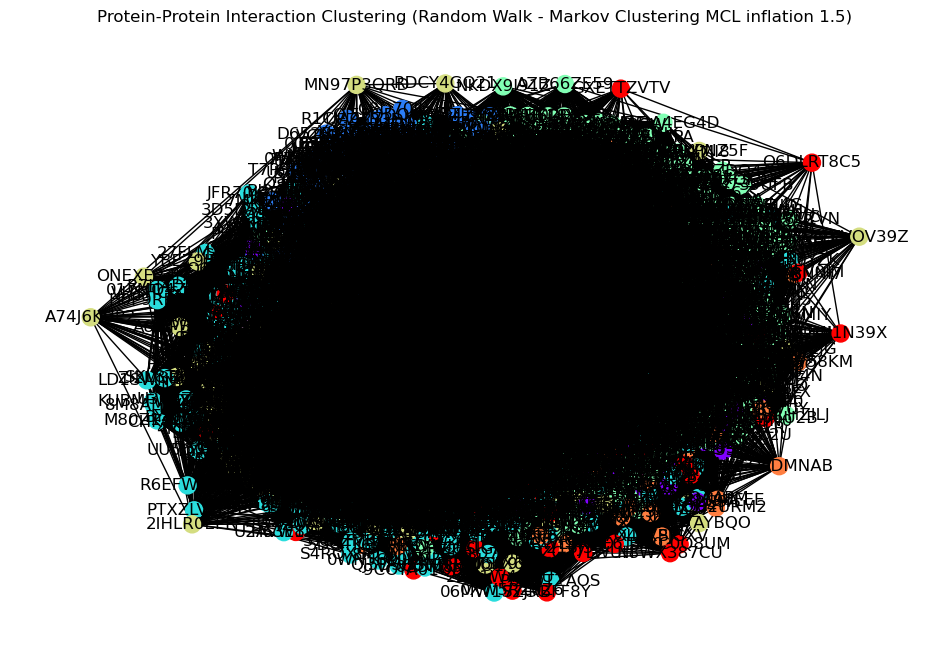

In [52]:
# Ensure all nodes in G have an assigned cluster (avoid KeyError)
colors = [protein_cluster_map.get(node, 0) for node in G.nodes()]  # Assign default cluster 0 if missing

# Convert colors to a NumPy array to ensure numeric values (prevents TypeErrors)
colors = np.array(colors, dtype=float)

# Draw the graph
fig, ax = plt.subplots(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.5)  # Layout for better visualization
nx.draw(G, pos, node_color=colors, with_labels=True, cmap=plt.cm.rainbow, node_size=150, ax=ax)

# Show the plot
plt.title("Protein-Protein Interaction Clustering (Random Walk - Markov Clustering MCL inflation 1.5)")
plt.show()